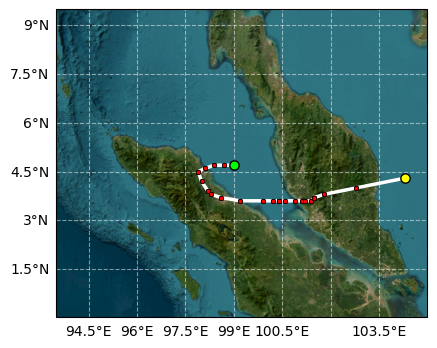

✅ PLOT & DATA SELESAI


In [20]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

in_nc  = r"D:\Kuliah\Skripsi\Olah data\Data_Siklon.nc"
out_png = r"D:\Kuliah\Skripsi\Olah data\Lintasan_Senyar_ESRI.png"

ds = xr.open_dataset(in_nc)

names = ds["name"].values
names = [n.decode("utf-8").strip() if isinstance(n, (bytes, bytearray)) else str(n).strip() for n in names]

idx = [i for i, n in enumerate(names) if n == "SENYAR"]
ds = ds.isel(storm=idx[0])

df = ds.to_dataframe().reset_index()

df["iso_time"] = df["iso_time"].apply(
    lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x
)
df["iso_time"] = pd.to_datetime(df["iso_time"], errors="coerce")

cols = ["iso_time", "basin", "usa_lat", "usa_lon", "usa_wind", "usa_pres", "dist2land", "usa_r34", "usa_rmw"]
df = df[[c for c in cols if c in df.columns]]

for c in ["usa_lat", "usa_lon", "usa_wind", "usa_pres"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["usa_lat", "usa_lon", "usa_wind", "usa_pres"])
df = df.sort_values("iso_time")

df.insert(0, "name", "SENYAR")

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(
        lambda x: x.decode('utf-8').strip() if isinstance(x, (bytes, bytearray)) else str(x).strip()
    )

tiler = cimgt.GoogleTiles(
    url='https://server.arcgisonline.com/ArcGIS/rest/services/'
        'World_Imagery/MapServer/tile/{z}/{y}/{x}.jpg'
)

fig = plt.figure(figsize=(6, 4))
ax = plt.axes(projection=tiler.crs)

# extent
ax.set_extent([93.5, 105.0, 0, 9.5])

# basemap
ax.add_image(tiler, 6)

# gridline
gl = ax.gridlines(draw_labels=True, linestyle="--", color="white", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# lintasan
ax.plot(
    df["usa_lon"], df["usa_lat"],
    color="white", linewidth=2.5,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="Lintasan Siklon Senyar"
)

# scatter tekanan
scatter = ax.scatter(
    df["usa_lon"], df["usa_lat"],
    c="red",
    edgecolor="black",
    linewidth=0.5,
    s=10,
    alpha=0.95,
    transform=ccrs.PlateCarree(),
    zorder=7
)

# START & END POINT
start_lon = df["usa_lon"].iloc[0]
start_lat = df["usa_lat"].iloc[0]

end_lon = df["usa_lon"].iloc[-1]
end_lat = df["usa_lat"].iloc[-1]

# titik awal
ax.scatter(
    start_lon, start_lat,
    color="lime",
    edgecolor="black",
    s=45,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=8,
    label="Mulai"
)

# titik akhir
ax.scatter(
    end_lon, end_lat,
    color="yellow",
    edgecolor="black",
    s=45,
    marker="o",
    transform=ccrs.PlateCarree(),
    zorder=8,
    label="Selesai"
)

# save
plt.savefig(out_png, dpi=1000, bbox_inches="tight", facecolor="white")
plt.show()

print("✅ PLOT & DATA SELESAI")

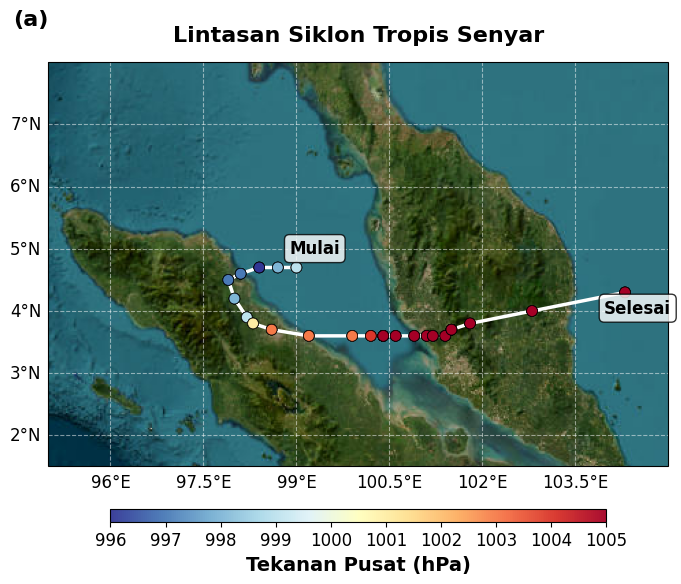

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

def beri_label_panel(ax, teks_label):
    ax.text(0.0, 1.08, teks_label, 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            ha='right',
            zorder=20)

in_nc  = r"D:\Kuliah\Skripsi\Olah data\Data_Siklon.nc"
out_txt = r"D:\Kuliah\Skripsi\Data_Senyar.txt"
out_png = r"D:\Kuliah\Skripsi\Olah data\Lintasan_Senyar.png"

ds = xr.open_dataset(in_nc)
names = ds["name"].values
names = [n.decode("utf-8").strip() if isinstance(n, (bytes, bytearray)) else str(n).strip() for n in names]

idx = [i for i, n in enumerate(names) if n == "SENYAR"]
ds = ds.isel(storm=idx[0])
df = ds.to_dataframe().reset_index()

df["iso_time"] = df["iso_time"].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)
df["iso_time"] = pd.to_datetime(df["iso_time"], errors="coerce")

cols = ["iso_time", "basin", "usa_lat", "usa_lon", "usa_wind", "usa_pres", "dist2land", "usa_r34", "usa_rmw"]
df = df[[c for c in cols if c in df.columns]]

for c in ["usa_lat", "usa_lon", "usa_wind", "usa_pres"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["usa_lat", "usa_lon", "usa_wind", "usa_pres"])
df = df.sort_values("iso_time")
df.insert(0, "name", "SENYAR")

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(lambda x: x.decode('utf-8').strip() if isinstance(x, (bytes, bytearray)) else str(x).strip())

tiler = cimgt.GoogleTiles(url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}.jpg')

fig = plt.figure(figsize=(8, 7))
ax = plt.axes(projection=tiler.crs)

beri_label_panel(ax, '(a)')

ax.set_extent([95, 105.0, 1.5, 8.0])
ax.add_image(tiler, 6)

gl = ax.gridlines(draw_labels=True, linestyle="--", color="white", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

ax.plot(df["usa_lon"], df["usa_lat"], color="white", linewidth=2.5, transform=ccrs.PlateCarree(), zorder=6, label="Lintasan Siklon Senyar")

scatter = ax.scatter(df["usa_lon"], df["usa_lat"], c=df["usa_pres"], cmap="RdYlBu_r", edgecolor="black", linewidth=0.5, s=60, alpha=0.95, transform=ccrs.PlateCarree(), zorder=7)

lon_start, lat_start = df["usa_lon"].iloc[0], df["usa_lat"].iloc[0]
lon_end, lat_end = df["usa_lon"].iloc[-1], df["usa_lat"].iloc[-1]

ax.annotate("Mulai", xy=(lon_start, lat_start), xytext=(-5, 10), textcoords="offset points", color="black", fontsize=12, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8), transform=ccrs.PlateCarree(), zorder=10)
ax.annotate("Selesai", xy=(lon_end, lat_end), xytext=(-15, -15), textcoords="offset points", color="black", fontsize=12, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8), transform=ccrs.PlateCarree(), zorder=10)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.08, aspect=40, shrink=0.8)
cbar.set_label("Tekanan Pusat (hPa)", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.title('Lintasan Siklon Tropis Senyar', fontweight='bold', color='black', fontsize=16, pad=15)
plt.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

df.to_csv(out_txt, sep="\t", index=False)

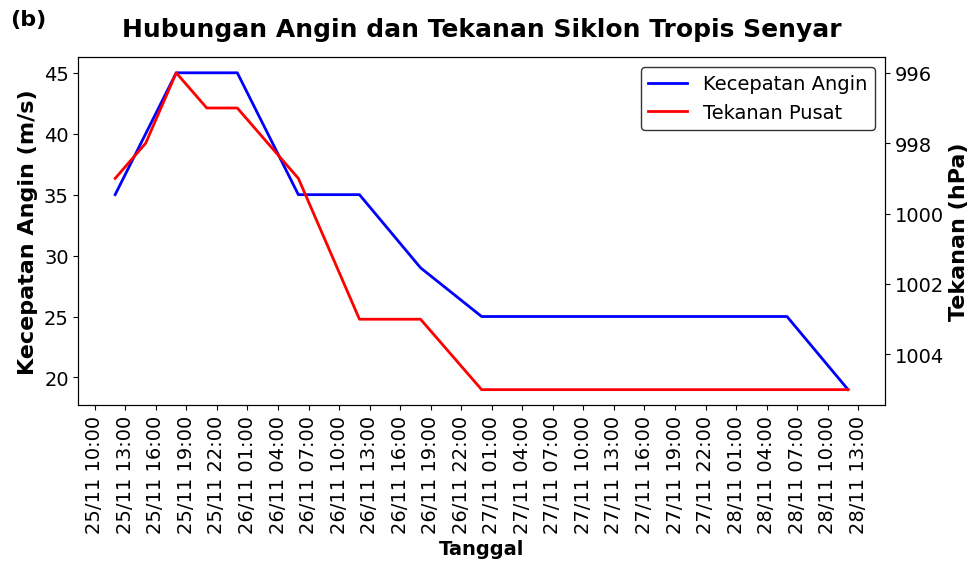

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def beri_label_panel(ax, teks_label):
    ax.text(-0.04, 1.08, teks_label, 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            ha='right',
            zorder=20)

out_png = r"D:\Kuliah\Skripsi\Olah data\time series_pres_wind.png"

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'font.family': 'sans-serif',
    'font.size': 14
})

fig, ax1 = plt.subplots(figsize=(10, 6))

beri_label_panel(ax1, '(b)')

line1, = ax1.plot(df['iso_time'], df['usa_wind'], color='blue', linewidth=2.0, label='Kecepatan Angin')

ax1.set_ylabel('Kecepatan Angin (m/s)', color='black', fontweight='bold', fontsize=16)

ax1.tick_params(axis='y', labelcolor='black', labelsize=14)

ax2 = ax1.twinx()
line2, = ax2.plot(df['iso_time'], df['usa_pres'], color='red', linewidth=2.0, label='Tekanan')
ax2.set_ylabel('Tekanan (hPa)', color='black', fontweight='bold', fontsize=16)
ax2.tick_params(axis='y', labelcolor='black', labelsize=14)
ax2.invert_yaxis()

ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))

ax1.tick_params(axis='x', labelsize=14) 
ax1.set_xlabel('Tanggal', fontweight='bold', fontsize=14)
plt.setp(ax1.get_xticklabels(), rotation=90, color='black')

legend = ax1.legend([line1, line2], ['Kecepatan Angin', 'Tekanan Pusat'], loc='best', frameon=True, edgecolor='black', fontsize=14)
for text in legend.get_texts():
    text.set_color('black')

plt.title('Hubungan Angin dan Tekanan Siklon Tropis Senyar', fontweight='bold', color='black', fontsize=18, pad=15)

plt.tight_layout()
plt.savefig(out_png, dpi=1000, bbox_inches='tight')
plt.show()